# Conformer Model - Dataset Ravdess MFCC 17
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_17.csv

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, LayerNormalization, Dropout, 
                                   MultiHeadAttention, Conv1D, GlobalAveragePooling1D)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset d01
dataset_path = '../dataset Ravdess 17/data_features_17.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (4320, 18)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', 'label']

Label distribution:
label
sad        960
angry      960
fear       960
disgust    960
neutral    480
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,label
0,-694.231506,50.040554,0.552267,14.545629,3.444762,-2.469327,-3.988867,-10.599405,-7.204890,1.954130,-4.295282,2.268538,-5.363429,3.054315,-3.309441,-2.942757,-2.452306,neutral
1,-401.955142,16.594981,5.987089,6.042175,1.752080,-2.039023,-4.436980,-6.726561,-5.315363,-1.916592,-1.055923,-0.764107,-0.872393,-0.780318,-1.666982,-2.502364,-0.485370,neutral
2,-696.260132,50.234077,0.570009,14.691901,3.428619,-2.418045,-3.920768,-10.508780,-7.109564,1.930409,-4.205997,2.327586,-5.371572,3.101801,-3.392733,-2.925853,-2.445413,neutral
3,-706.712158,47.825089,-0.674069,14.761738,2.468847,-4.197237,-6.947045,-11.992122,-5.492224,1.690096,-3.298837,1.515934,-4.570371,2.751648,-4.609617,-2.627003,-1.220259,neutral
4,-706.450291,51.669993,-0.672582,11.109251,0.728495,-3.095116,-7.086010,-14.615463,-9.870567,2.474204,-4.442304,2.910798,-4.813171,4.366810,-2.132010,-3.655878,-2.798525,neutral


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (4320, 18)

Class distribution after filtering:
   sad: 960 samples (22.2%)
   angry: 960 samples (22.2%)
   fear: 960 samples (22.2%)
   disgust: 960 samples (22.2%)
   neutral: 480 samples (11.1%)

Features shape: (4320, 17)
Number of features: 17
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for model input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 3456
Test samples: 864
Reshaped train data: (3456, 17, 1)
Reshaped test data: (864, 17, 1)
Categorical labels shape: (3456, 5)


In [5]:
# Create Conformer model
def create_conformer_block(embed_dim, num_heads, ff_dim, rate=0.1):
    """Create a Conformer block"""
    def conformer_block(inputs):
        # Multi-Head Self Attention
        attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
        attn_output = Dropout(rate)(attn_output)
        out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)
        
        # Convolutional Module
        conv_output = Conv1D(filters=embed_dim, kernel_size=3, padding="same", activation="relu")(out1)
        conv_output = Dropout(rate)(conv_output)
        out2 = LayerNormalization(epsilon=1e-6)(out1 + conv_output)
        
        # Feed Forward Network
        ffn_output = Dense(ff_dim, activation="relu")(out2)
        ffn_output = Dense(embed_dim)(ffn_output)
        ffn_output = Dropout(rate)(ffn_output)
        
        return LayerNormalization(epsilon=1e-6)(out2 + ffn_output)
    
    return conformer_block

def create_conformer_model(input_shape, num_classes=5, embed_dim=64, num_heads=4, ff_dim=128):
    """Create Conformer model for emotion recognition"""
    
    inputs = Input(shape=input_shape)
    
    # Input projection
    x = Dense(embed_dim)(inputs)
    
    # Conformer blocks
    conformer_block = create_conformer_block(embed_dim, num_heads, ff_dim)
    x = conformer_block(x)
    x = conformer_block(x)
    
    # Global pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification head
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='Conformer_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_conformer_model(input_shape)

# Compile model
model.compile(
    optimizer=Adam (learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Conformer model created and compiled!")
model.summary()

Conformer model created and compiled!


Model: "Conformer_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 17, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 17, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 17, 64)    │     66,368 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 17, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 17, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 17, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 17, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 17, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 17, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 17, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 17, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 17, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 17, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 17, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 17, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 17, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 17, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 17, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 17, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 208,389 (814.02 KB)

 Trainable params: 208,389 (814.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2281 - loss: 1.6537 - val_accuracy: 0.2963 - val_loss: 1.5552 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2827 - loss: 1.5523 - val_accuracy: 0.3090 - val_loss: 1.5042 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3182 - loss: 1.4967 - val_accuracy: 0.3356 - val_loss: 1.4580 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3288 - loss: 1.4714 - val_accuracy: 0.3403 - val_loss: 1.4458 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3628 - loss: 1.4196 - val_accuracy: 0.3704 - val_loss: 1.3446 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3900 - loss: 1.3437 - val_accuracy: 0.4132 - val_loss: 1.3447 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step -

In [7]:
# Evaluation and Results
print("CONFORMER MODEL EVALUATION - Dataset Ravdess MFCC 17")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CONFORMER MODEL EVALUATION - Dataset Ravdess MFCC 17
Test Accuracy: 0.7419
Test Loss: 0.8546

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.8343    0.7604    0.7956       192
     disgust     0.6893    0.7396    0.7136       192
        fear     0.7030    0.7396    0.7208       192
     neutral     0.8077    0.6562    0.7241        96
         sad     0.7291    0.7708    0.7494       192

    accuracy                         0.7419       864
   macro avg     0.7527    0.7333    0.7407       864
weighted avg     0.7466    0.7419    0.7425       864


Cohen's Kappa Score: 0.6724

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.8588
Final Validation Accuracy: 0.7373
Epochs Trained: 100



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   146       27        15        1         3         
disgust 14        142       22        3         11        
fear    12        19        142       2         17        
neutral 0         5         4         63        24        
sad     3         13        19        9         148       


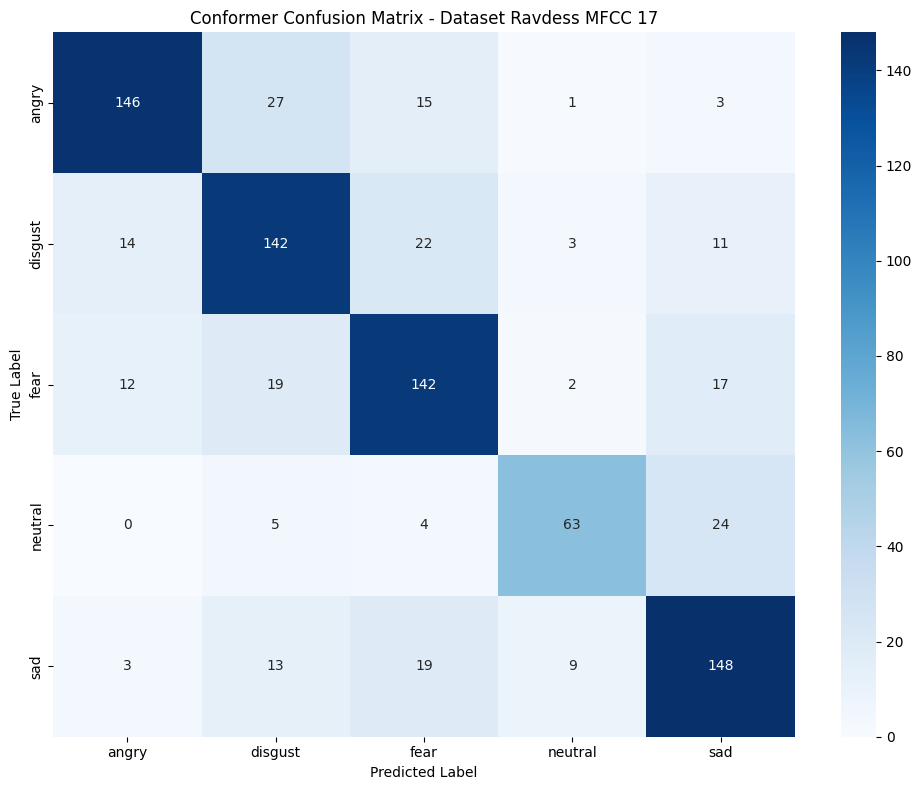

In [8]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Conformer Confusion Matrix - Dataset Ravdess MFCC 17')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

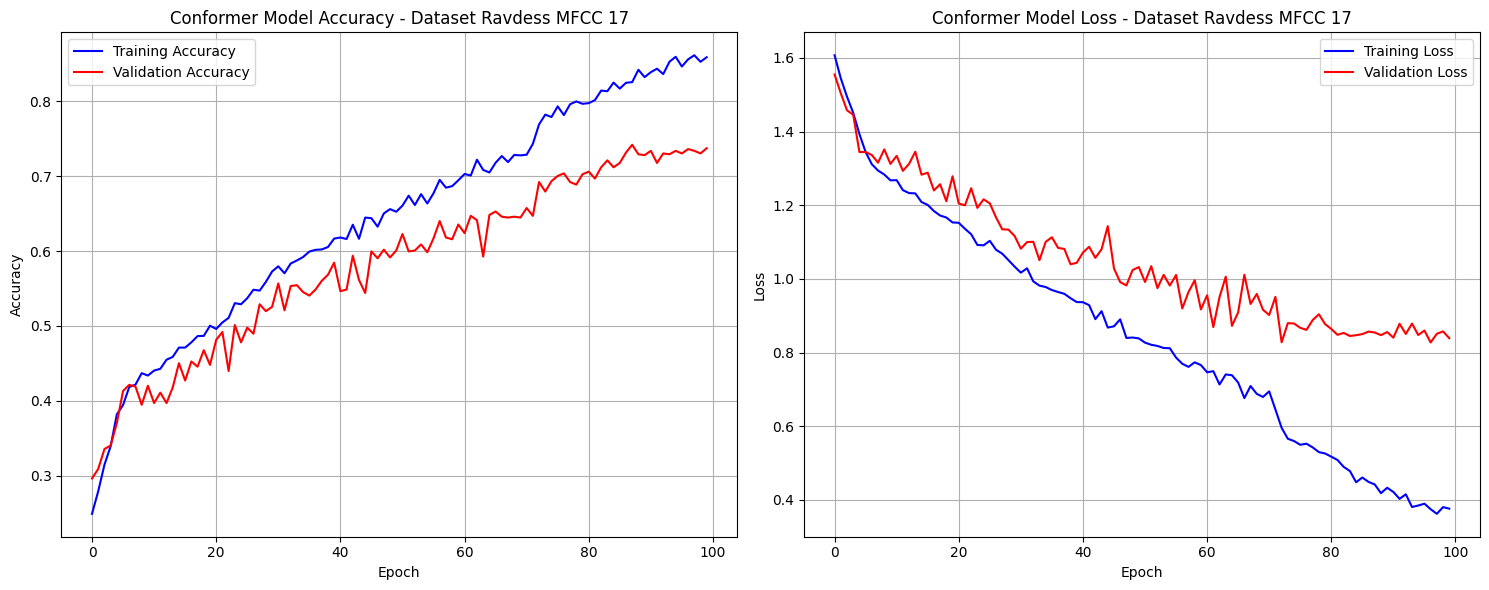

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Conformer Model Accuracy - Dataset Ravdess MFCC 17')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Conformer Model Loss - Dataset Ravdess MFCC 17')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [ ]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - Conformer Ravdess MFCC 17")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_17.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - Conformer Ravdess MFCC 17
Test Accuracy: 0.7419
Cohen's Kappa: 0.6724
Epochs Trained: 100
Dataset: data_features_17.csv
Classes: angry, disgust, fear, neutral, sad


: 